# Week 7: Model Evaluation and Validation

This notebook covers:
1. Sklearn refresher: fit / predict / score
2. Train/test split variance
3. Model complexity and overfitting
4. Validation sets
5. K-Fold cross-validation
6. CV variants (Stratified, TimeSeries)
7. Data leakage
8. Learning and validation curves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold,
    validation_curve, learning_curve
)
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
%config InlineBackend.figure_format = 'retina'
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All imports loaded.")

All imports loaded.


---
## Part 1: Sklearn Refresher

The sklearn API has three key methods: `fit`, `predict`, `score`.
Let's build a synthetic "movie rating" dataset and train three classifiers.

In [2]:
from sklearn.datasets import make_classification

# Synthetic movie dataset: 1000 movies, 8 features
# Features might represent: budget, runtime, num_actors, marketing_spend, etc.
X_movies, y_movies = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=5,
    n_redundant=2,
    n_classes=2,          # 0 = flop, 1 = hit
    flip_y=0.1,           # 10% label noise
    random_state=42
)

feature_names = [
    'budget', 'runtime', 'num_actors', 'marketing_spend',
    'sequel', 'director_experience', 'genre_score', 'release_month'
]
df_movies = pd.DataFrame(X_movies, columns=feature_names)
df_movies['hit'] = y_movies

print(f"Dataset shape: {X_movies.shape}")
print(f"Class distribution: {np.bincount(y_movies)} (0=flop, 1=hit)")
df_movies.head()

Dataset shape: (1000, 8)
Class distribution: [492 508] (0=flop, 1=hit)


,budget,runtime,num_actors,marketing_spend,sequel,director_experience,genre_score,release_month,hit
0,2.014767,1.039113,-1.658318,2.295400,4.038748,-1.701969,-0.781009,-1.454859,0
1,1.480414,-1.997225,0.431374,3.858429,3.112322,1.079546,-0.842906,0.424517,0
2,-0.473274,2.978732,-1.462023,-0.829122,0.254840,-0.812232,-1.253805,2.431122,1
3,2.317766,2.041602,-0.036033,1.782168,-0.093936,-1.430375,0.384279,-0.314547,0
4,1.233522,2.913766,0.057914,0.042333,-1.446088,-2.156472,1.100664,-0.157955,1


In [ ]:
# Can features be negative? Yes, due to the way make_classification generates data.
# In a real dataset, features like budget or marketing spend would not be negative,
# but for this synthetic dataset, we will proceed with the generated values.

# We will also assume we normalized the features to have a mean of 0 and a standard deviation of 1, 
# which is common in synthetic datasets created for classification tasks.


In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_movies, y_movies, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 800 samples, Test: 200 samples


In [4]:
# The sklearn pattern: fit -> predict -> score
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    # Step 1: fit
    model.fit(X_train, y_train)
    
    # Step 2: predict
    y_pred = model.predict(X_test)
    
    # Step 3: score
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test, y_test)
    
    print(f"{name:25s}  Train: {train_acc:.3f}  Test: {test_acc:.3f}  Gap: {train_acc - test_acc:+.3f}")

Logistic Regression        Train: 0.796  Test: 0.830  Gap: -0.034
Decision Tree              Train: 1.000  Test: 0.780  Gap: +0.220
Random Forest              Train: 1.000  Test: 0.885  Gap: +0.115


**Takeaway:** The Decision Tree has a large train-test gap -- a sign of overfitting.
The Random Forest and Logistic Regression generalize better.

---
## Part 2: Train/Test Split Variance

A single train/test split is **noisy**. Different random seeds give different scores.
Let's repeat the split 50 times and see how much the score varies.

In [5]:
n_splits = 50
rf_scores = []

for seed in range(n_splits):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_movies, y_movies, test_size=0.2, random_state=seed
    )
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_tr, y_tr)
    rf_scores.append(rf.score(X_te, y_te))

rf_scores = np.array(rf_scores)

print(f"Mean accuracy:  {rf_scores.mean():.3f}")
print(f"Std deviation:  {rf_scores.std():.3f}")
print(f"Min:            {rf_scores.min():.3f}")
print(f"Max:            {rf_scores.max():.3f}")
print(f"Range:          {rf_scores.max() - rf_scores.min():.3f}")
print(f"\nThat is a {(rf_scores.max() - rf_scores.min())*100:.1f} percentage point swing!")

Mean accuracy:  0.887
Std deviation:  0.021
Min:            0.845
Max:            0.935
Range:          0.090

That is a 9.0 percentage point swing!


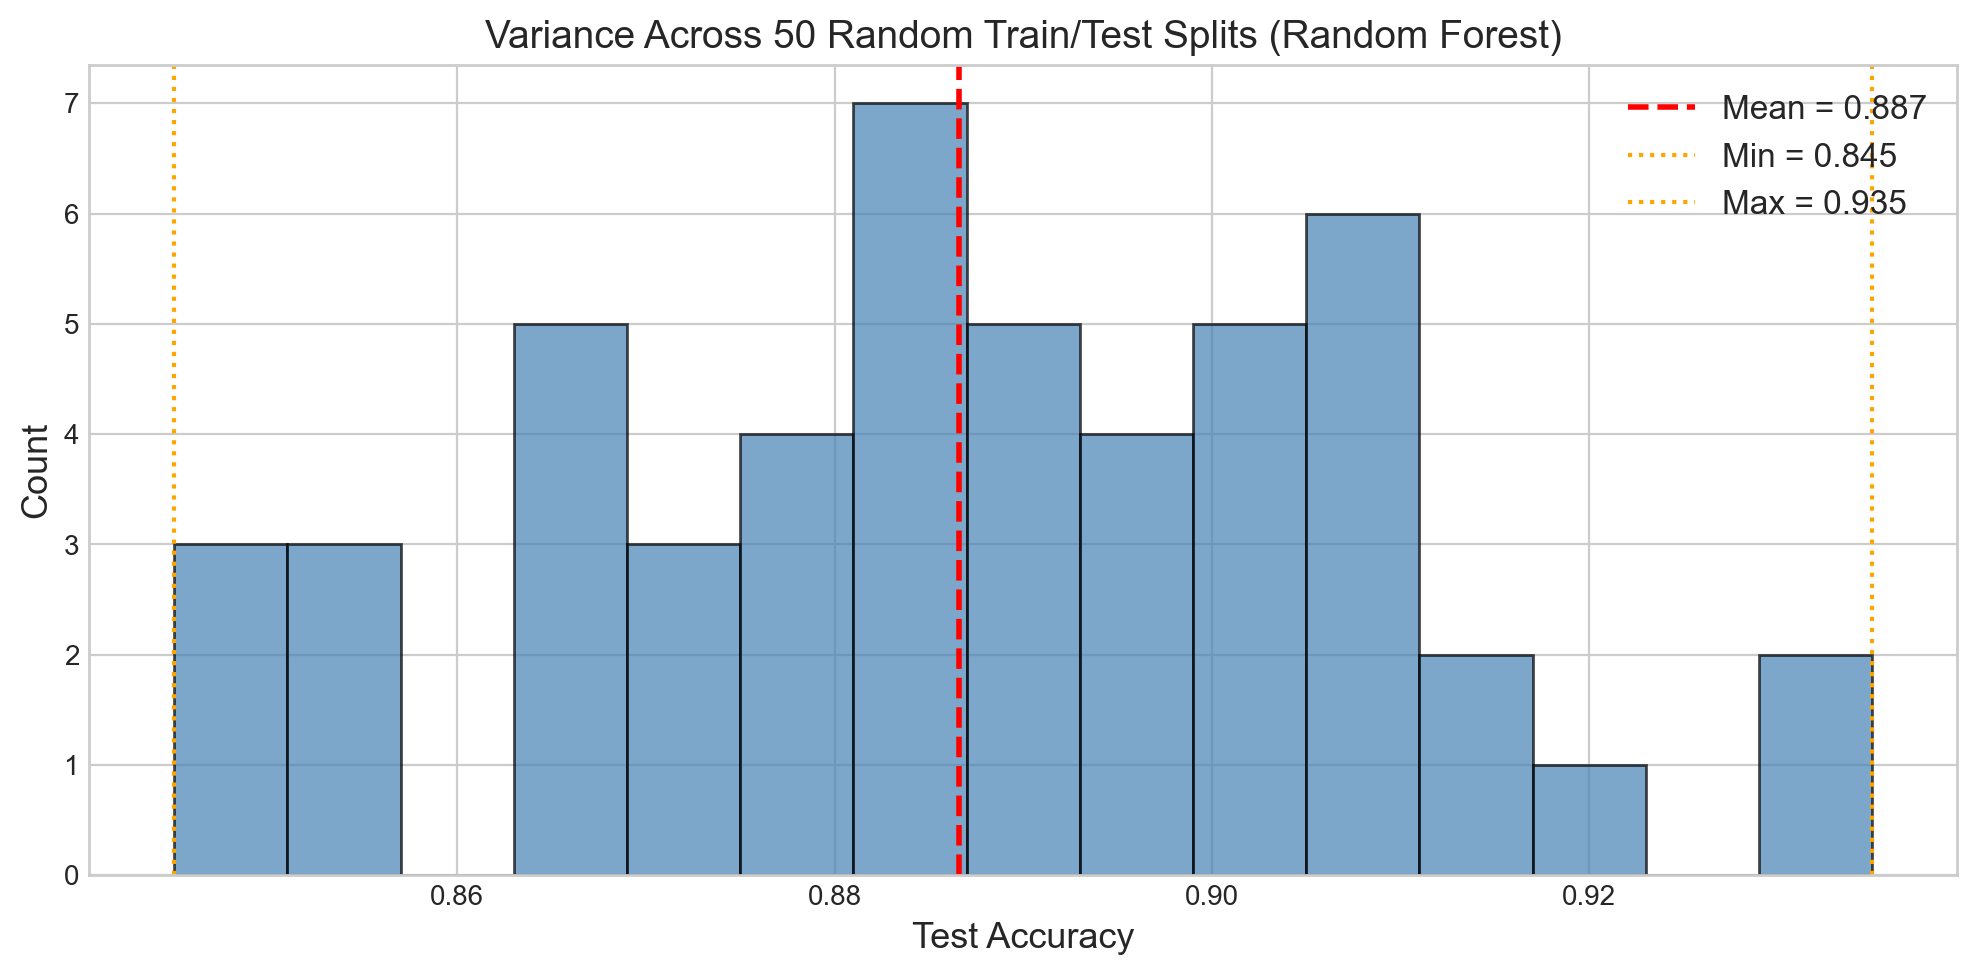

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(rf_scores, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(rf_scores.mean(), color='red', linewidth=2, linestyle='--',
           label=f'Mean = {rf_scores.mean():.3f}')
ax.axvline(rf_scores.min(), color='orange', linewidth=1.5, linestyle=':',
           label=f'Min = {rf_scores.min():.3f}')
ax.axvline(rf_scores.max(), color='orange', linewidth=1.5, linestyle=':',
           label=f'Max = {rf_scores.max():.3f}')
ax.set_xlabel('Test Accuracy', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Variance Across 50 Random Train/Test Splits (Random Forest)', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Takeaway:** A single train/test split is unreliable. You could get lucky or unlucky.
We need a more stable evaluation strategy -- that is where cross-validation comes in.

---
## Part 3: Model Complexity

### 3a. Polynomial Regression (Underfitting vs Overfitting)

In [25]:
# Generate 1D regression data: y = sin(x) + noise
np.random.seed(42)
n_reg = 30
X_reg = np.sort(np.random.uniform(0, 2 * np.pi, n_reg)).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + np.random.normal(0, 0.25, n_reg)

# Split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

# Smooth line for plotting
X_plot = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)

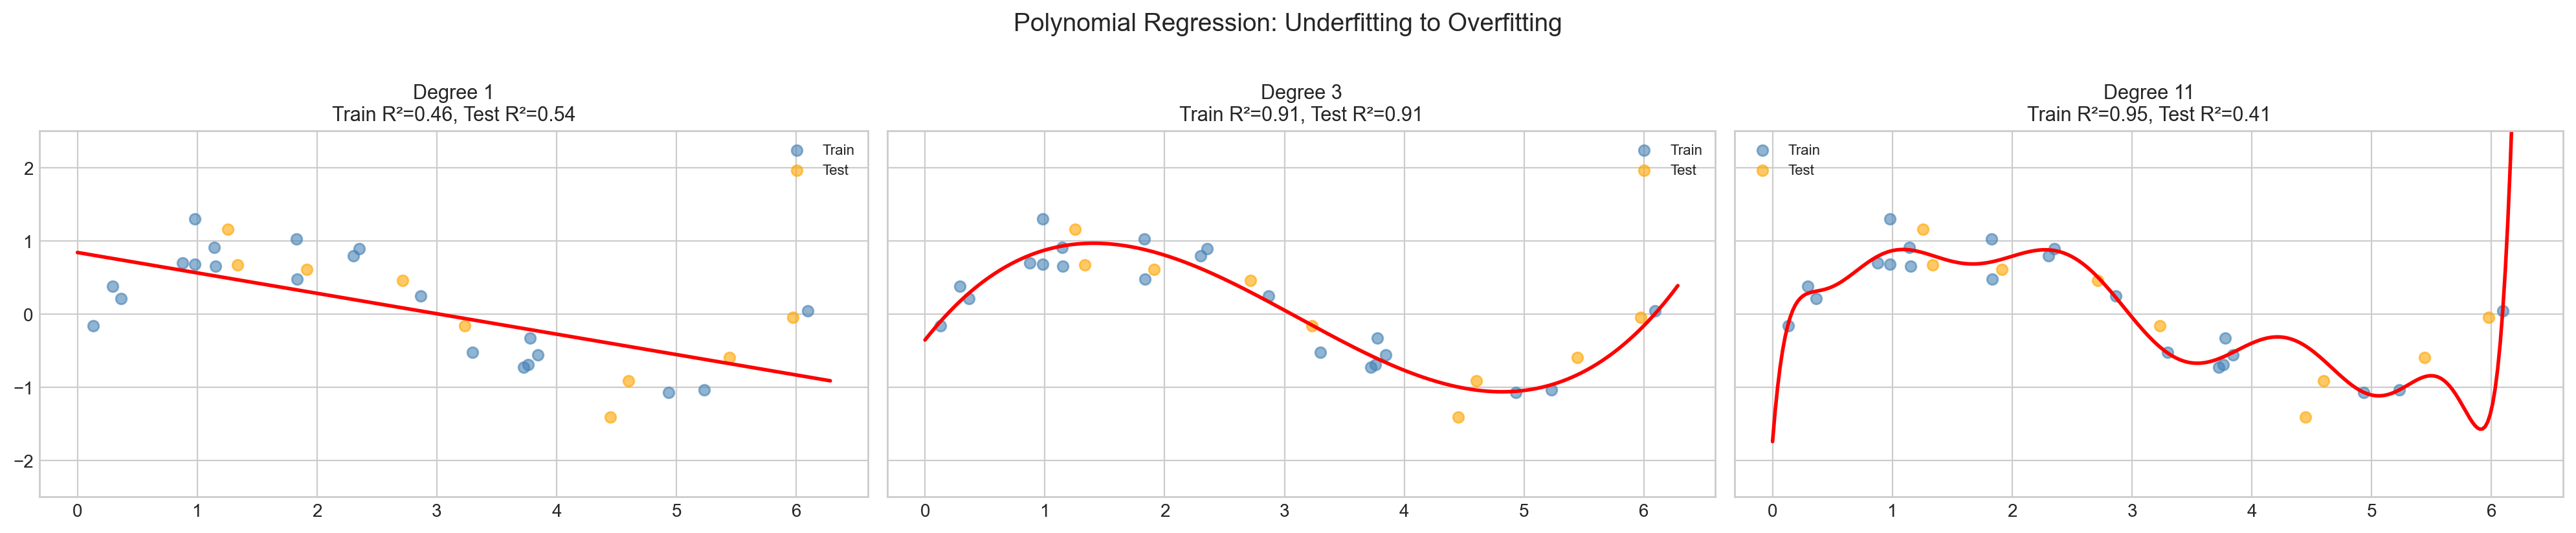

In [27]:
degrees = [1, 3, 11]

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharey=True)

train_r2s = []
test_r2s = []

for ax, deg in zip(axes, degrees):
    # Build pipeline: polynomial features + linear regression
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(X_reg_train, y_reg_train)
    
    train_r2 = pipe.score(X_reg_train, y_reg_train)
    test_r2  = pipe.score(X_reg_test, y_reg_test)
    train_r2s.append(train_r2)
    test_r2s.append(test_r2)
    
    # Plot
    y_plot = pipe.predict(X_plot)
    ax.scatter(X_reg_train, y_reg_train, color='steelblue', alpha=0.6, label='Train')
    ax.scatter(X_reg_test, y_reg_test, color='orange', alpha=0.6, label='Test')
    ax.plot(X_plot, y_plot, color='red', linewidth=2)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f'Degree {deg}\nTrain R²={train_r2:.2f}, Test R²={test_r2:.2f}', fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle('Polynomial Regression: Underfitting to Overfitting', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Summary table
print(f"{'Degree':>8}  {'Train R²':>10}  {'Test R²':>10}  {'Gap':>8}")
print('-' * 42)
for deg, tr, te in zip(degrees, train_r2s, test_r2s):
    print(f"{deg:>8}  {tr:>10.3f}  {te:>10.3f}  {tr - te:>+8.3f}")

  Degree    Train R²     Test R²       Gap
------------------------------------------
       1       0.457       0.536    -0.079
       3       0.912       0.914    -0.002
      11       0.947       0.408    +0.539


### 3b. Decision Tree Depth (Classification)

In [36]:
from sklearn.datasets import make_moons

# Generate 2D classification data for nice decision boundaries
X_moons, y_moons = make_moons(n_samples=100, noise=0.5, random_state=42)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

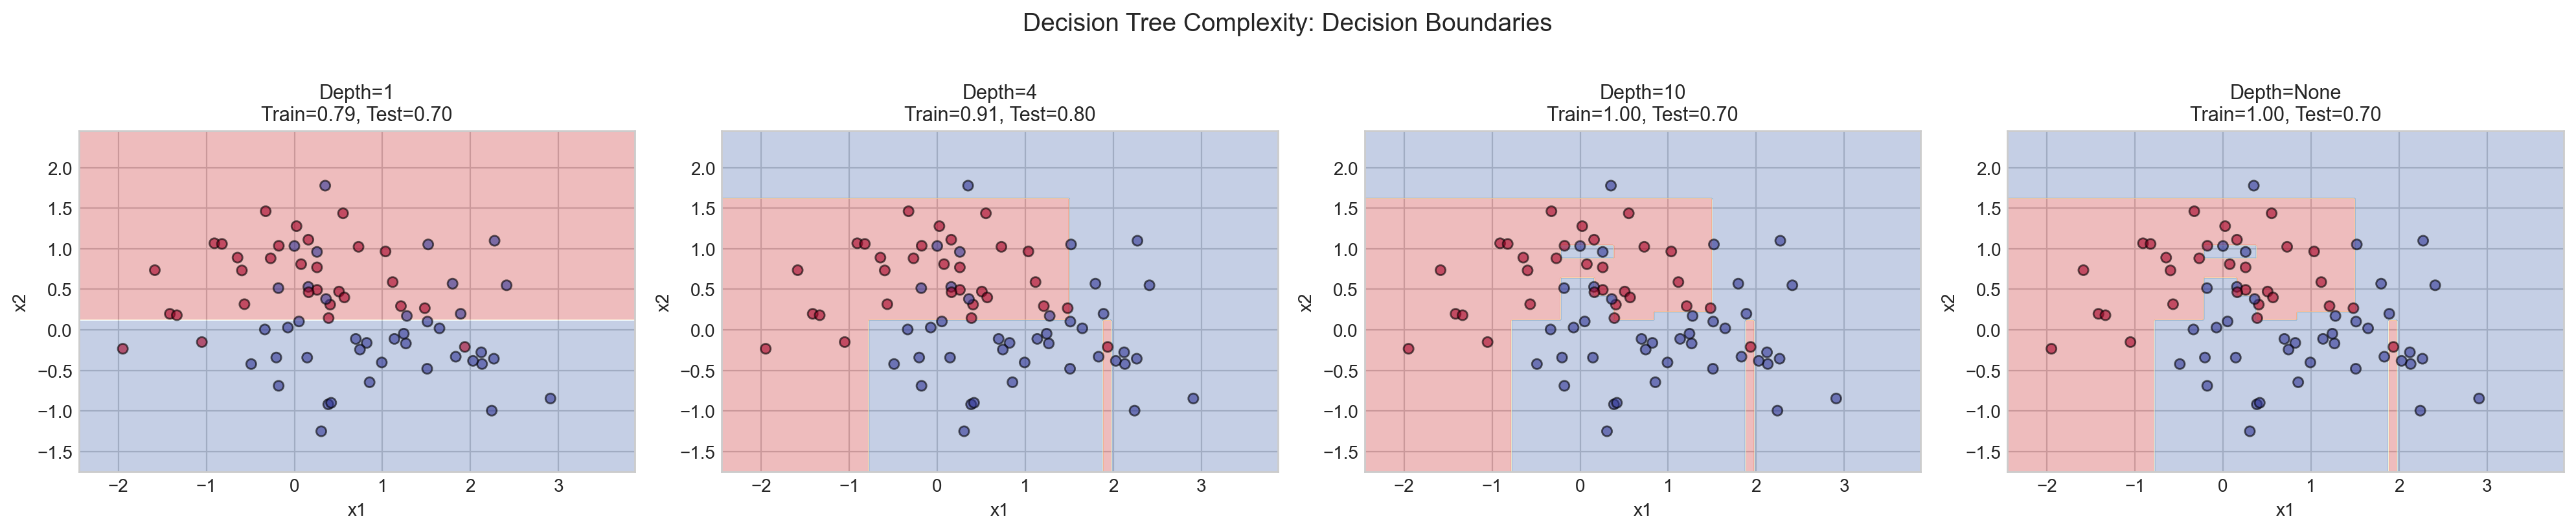

In [37]:
tree_depths = [1, 4, 10, None]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Create meshgrid for decision boundary
h = 0.02
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))

for ax, depth in zip(axes, tree_depths):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_m_train, y_m_train)
    
    train_acc = dt.score(X_m_train, y_m_train)
    test_acc  = dt.score(X_m_test, y_m_test)
    
    # Decision boundary
    Z = dt.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X_m_train[:, 0], X_m_train[:, 1], c=y_m_train,
               cmap='RdYlBu', edgecolors='k', s=30, alpha=0.6)
    
    depth_str = str(depth) if depth is not None else 'None'
    ax.set_title(f'Depth={depth_str}\nTrain={train_acc:.2f}, Test={test_acc:.2f}', fontsize=11)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')

fig.suptitle('Decision Tree Complexity: Decision Boundaries', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

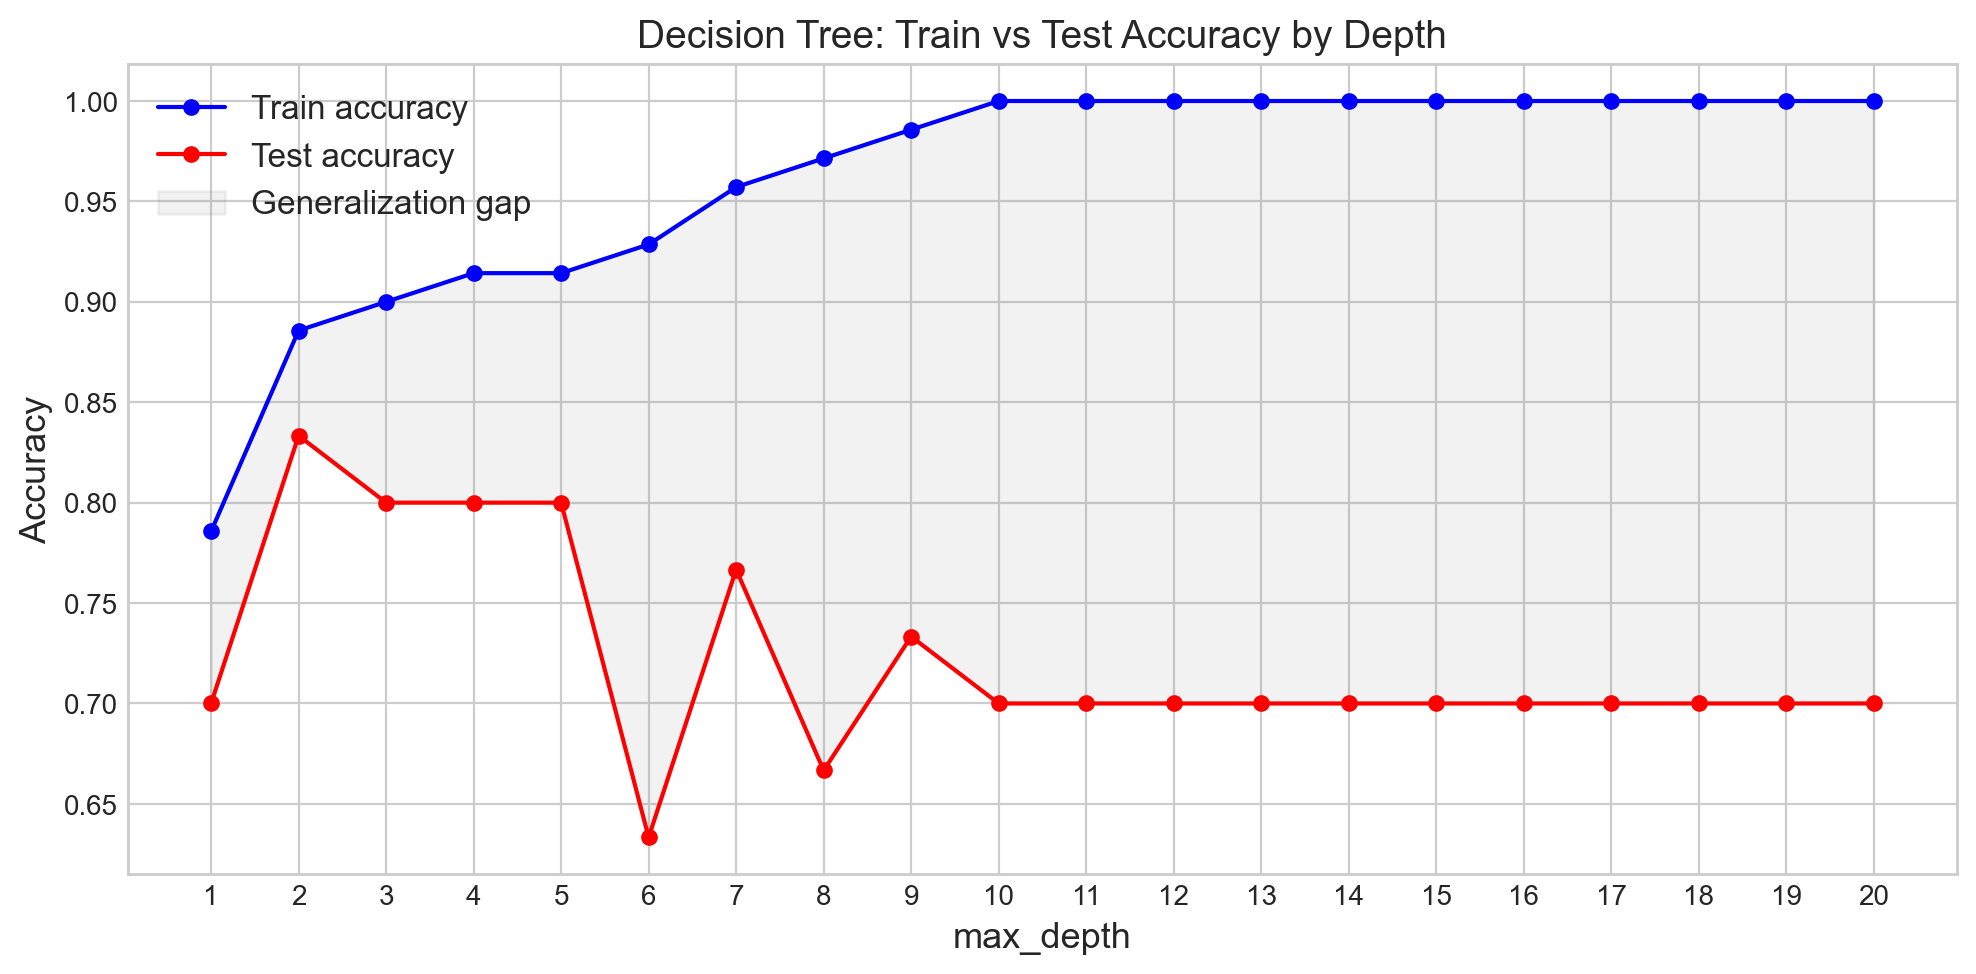

In [38]:
# Train vs test across all depths
all_depths = list(range(1, 21))
train_accs = []
test_accs = []

for d in all_depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_m_train, y_m_train)
    train_accs.append(dt.score(X_m_train, y_m_train))
    test_accs.append(dt.score(X_m_test, y_m_test))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(all_depths, train_accs, 'b-o', label='Train accuracy', markersize=5)
ax.plot(all_depths, test_accs, 'r-o', label='Test accuracy', markersize=5)
ax.fill_between(all_depths, test_accs, train_accs, alpha=0.1, color='gray',
                label='Generalization gap')
ax.set_xlabel('max_depth', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Decision Tree: Train vs Test Accuracy by Depth', fontsize=14)
ax.legend(fontsize=12)
ax.set_xticks(all_depths)
plt.tight_layout()
plt.show()

**Takeaway:** As model complexity increases (higher degree, deeper tree), 
training performance goes up but test performance eventually drops. 
The gap between train and test is the **generalization gap**.

---
## Part 4: Validation Set

Use a **three-way split**: train / validation / test.  
- Train on the training set  
- Pick the best hyperparameter on the validation set  
- Report final performance on the test set (touched **once**)

In [39]:
# Three-way split: 60% train, 20% validation, 20% test
X_temp, X_final_test, y_temp, y_final_test = train_test_split(
    X_movies, y_movies, test_size=0.2, random_state=42
)
X_train_v, X_val, y_train_v, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42   # 0.25 * 0.8 = 0.2
)

print(f"Train:      {X_train_v.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_final_test.shape[0]} samples")

Train:      600 samples
Validation: 200 samples
Test:       200 samples


In [40]:
# Tune max_depth using the validation set
depth_range = list(range(1, 21))
val_scores = []
trn_scores = []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_v, y_train_v)
    trn_scores.append(dt.score(X_train_v, y_train_v))
    val_scores.append(dt.score(X_val, y_val))

best_depth = depth_range[np.argmax(val_scores)]
print(f"Best depth on validation set: {best_depth}")
print(f"Validation accuracy at best depth: {max(val_scores):.3f}")

Best depth on validation set: 7
Validation accuracy at best depth: 0.845


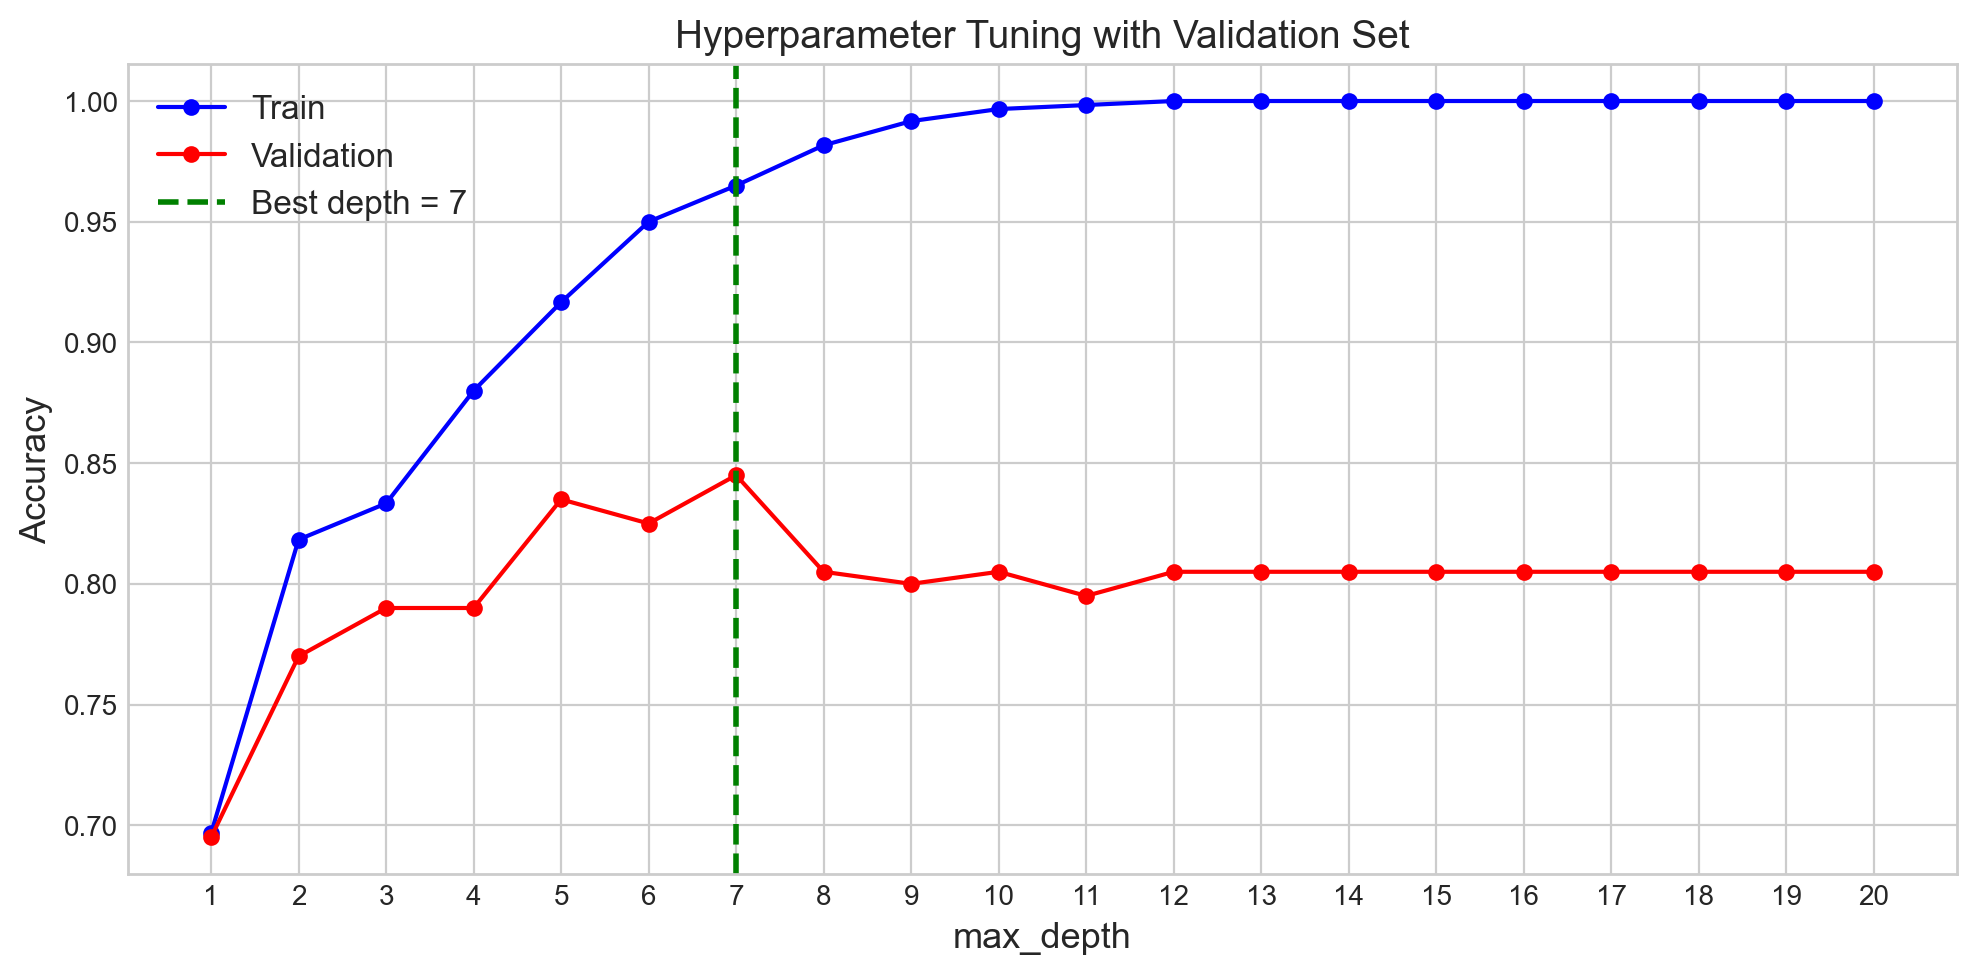

In [41]:
# Plot train vs validation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_range, trn_scores, 'b-o', label='Train', markersize=5)
ax.plot(depth_range, val_scores, 'r-o', label='Validation', markersize=5)
ax.axvline(best_depth, color='green', linestyle='--', linewidth=2,
           label=f'Best depth = {best_depth}')
ax.set_xlabel('max_depth', fontsize=13)
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('Hyperparameter Tuning with Validation Set', fontsize=14)
ax.legend(fontsize=12)
ax.set_xticks(depth_range)
plt.tight_layout()
plt.show()

In [42]:
# Final evaluation on test set (done ONCE)
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_train_v, y_train_v)

final_test_acc = final_model.score(X_final_test, y_final_test)
print(f"Final test accuracy (reported ONCE): {final_test_acc:.3f}")
print(f"Validation accuracy was:             {max(val_scores):.3f}")
print(f"\nThese should be close. If test << val, you may have overfit to validation.")

Final test accuracy (reported ONCE): 0.845
Validation accuracy was:             0.845

These should be close. If test << val, you may have overfit to validation.


---
## Part 5: K-Fold Cross-Validation

K-Fold CV uses **all** the data for both training and validation.
Each sample appears in exactly one validation fold.

In [43]:
# 5-fold CV on the movie dataset
rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf, X_movies, y_movies, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Results")
print("=" * 40)
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.3f}")
print(f"\n  Mean:  {cv_scores.mean():.3f}")
print(f"  Std:   {cv_scores.std():.3f}")
print(f"  Report as: {cv_scores.mean():.1%} +/- {cv_scores.std():.1%}")

5-Fold Cross-Validation Results
  Fold 1: 0.865
  Fold 2: 0.875
  Fold 3: 0.905
  Fold 4: 0.855
  Fold 5: 0.895

  Mean:  0.879
  Std:   0.019
  Report as: 87.9% +/- 1.9%


In [ ]:
# We can get above using for loop and manual splits, but cross_val_score does it all for us!

In [44]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

skf = StratifiedKFold(n_splits=5, shuffle=False)  # matches cross_val_score default

scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_movies, y_movies), 1):
    
    X_train, X_test = X_movies[train_idx], X_movies[test_idx]
    y_train, y_test = y_movies[train_idx], y_movies[test_idx]
    
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    
    scores.append(acc)
    print(f"  Fold {fold}: {acc:.3f}")

scores = np.array(scores)

print("\n5-Fold Cross-Validation Results")
print("=" * 40)
print(f"  Mean:  {scores.mean():.3f}")
print(f"  Std:   {scores.std():.3f}")
print(f"  Report as: {scores.mean():.1%} +/- {scores.std():.1%}")

  Fold 1: 0.865
  Fold 2: 0.875
  Fold 3: 0.905
  Fold 4: 0.855
  Fold 5: 0.895

5-Fold Cross-Validation Results
  Mean:  0.879
  Std:   0.019
  Report as: 87.9% +/- 1.9%


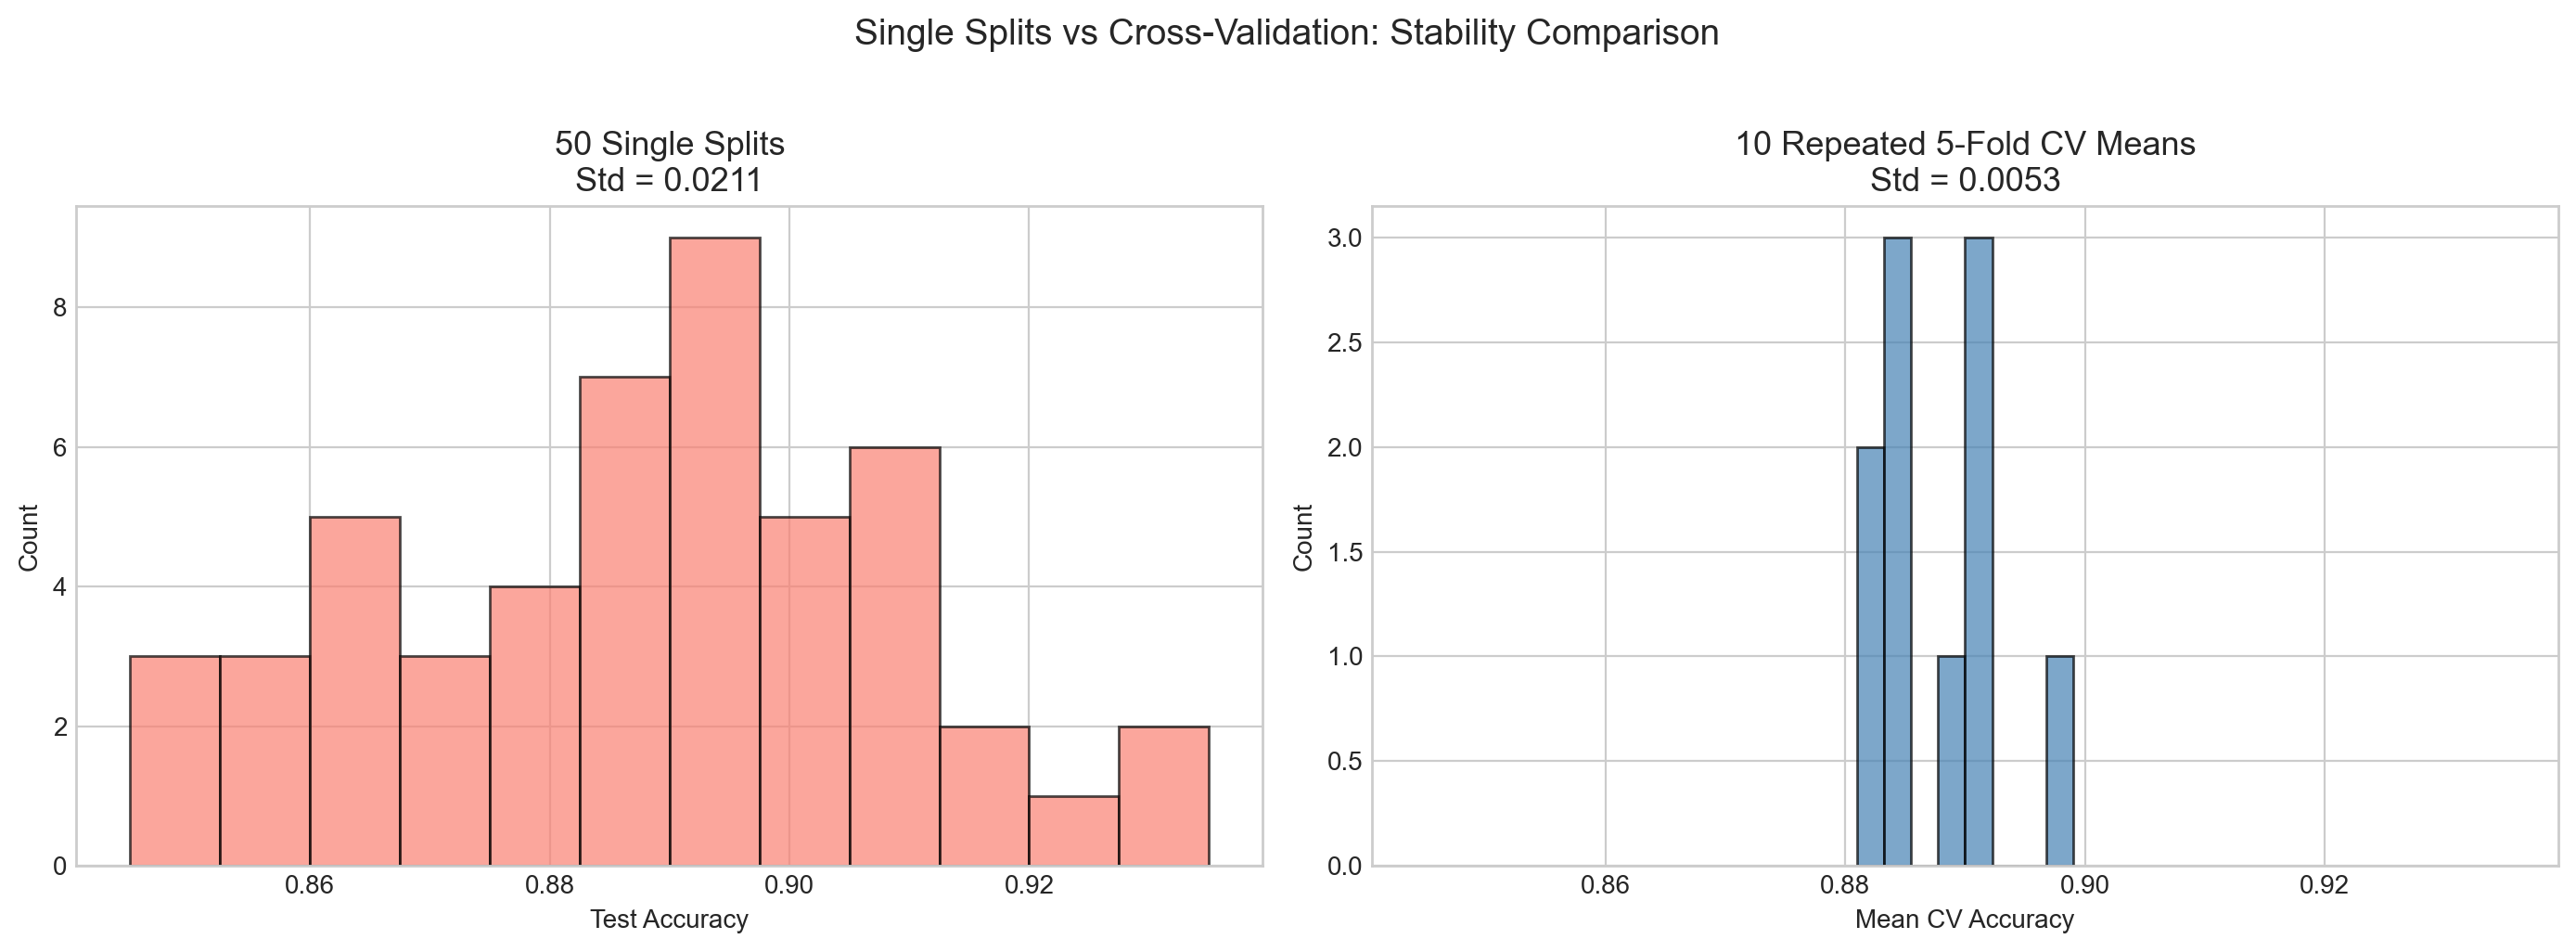

Single-split std:  0.0211
CV mean std:       0.0053
CV is ~4x more stable!


In [45]:
# Compare stability: single splits vs cross-validation

# Repeat single-split 50 times (from Part 2)
single_split_scores = rf_scores  # already computed above

# Repeat 5-fold CV 10 times with different shuffles
cv_means = []
for seed in range(10):
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(rf, X_movies, y_movies, cv=kf)
    cv_means.append(scores.mean())

cv_means = np.array(cv_means)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(single_split_scores, bins=12, edgecolor='black', alpha=0.7, color='salmon')
axes[0].set_title(f'50 Single Splits\nStd = {single_split_scores.std():.4f}', fontsize=13)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_ylabel('Count')

axes[1].hist(cv_means, bins=8, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title(f'10 Repeated 5-Fold CV Means\nStd = {cv_means.std():.4f}', fontsize=13)
axes[1].set_xlabel('Mean CV Accuracy')
axes[1].set_ylabel('Count')
axes[1].set_xlim(axes[0].get_xlim())  # same x-axis for comparison

fig.suptitle('Single Splits vs Cross-Validation: Stability Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Single-split std:  {single_split_scores.std():.4f}")
print(f"CV mean std:       {cv_means.std():.4f}")
print(f"CV is ~{single_split_scores.std() / cv_means.std():.0f}x more stable!")

---
## Part 6: CV Variants

### 6a. StratifiedKFold -- preserves class ratios

In [46]:
# Create an imbalanced dataset for demonstration
X_imb, y_imb = make_classification(
    n_samples=500, n_features=8, n_informative=4,
    weights=[0.8, 0.2],   # 80% class 0, 20% class 1
    random_state=42
)
print(f"Overall class ratio: {y_imb.mean():.2f} (class 1)")
print(f"Class counts: {np.bincount(y_imb)}")

Overall class ratio: 0.20 (class 1)
Class counts: [400 100]


In [47]:
# Compare regular KFold vs StratifiedKFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Regular KFold -- class 1 ratio per fold:")
for i, (train_idx, test_idx) in enumerate(kf.split(X_imb, y_imb), 1):
    ratio = y_imb[test_idx].mean()
    print(f"  Fold {i}: {ratio:.3f}  (n_test={len(test_idx)})")

print(f"\nStratifiedKFold -- class 1 ratio per fold:")
for i, (train_idx, test_idx) in enumerate(skf.split(X_imb, y_imb), 1):
    ratio = y_imb[test_idx].mean()
    print(f"  Fold {i}: {ratio:.3f}  (n_test={len(test_idx)})")

print(f"\nOverall ratio: {y_imb.mean():.3f}")
print("Stratified keeps every fold close to the overall ratio.")

Regular KFold -- class 1 ratio per fold:
  Fold 1: 0.200  (n_test=100)
  Fold 2: 0.170  (n_test=100)
  Fold 3: 0.210  (n_test=100)
  Fold 4: 0.220  (n_test=100)
  Fold 5: 0.200  (n_test=100)

StratifiedKFold -- class 1 ratio per fold:
  Fold 1: 0.200  (n_test=100)
  Fold 2: 0.200  (n_test=100)
  Fold 3: 0.200  (n_test=100)
  Fold 4: 0.200  (n_test=100)
  Fold 5: 0.200  (n_test=100)

Overall ratio: 0.200
Stratified keeps every fold close to the overall ratio.


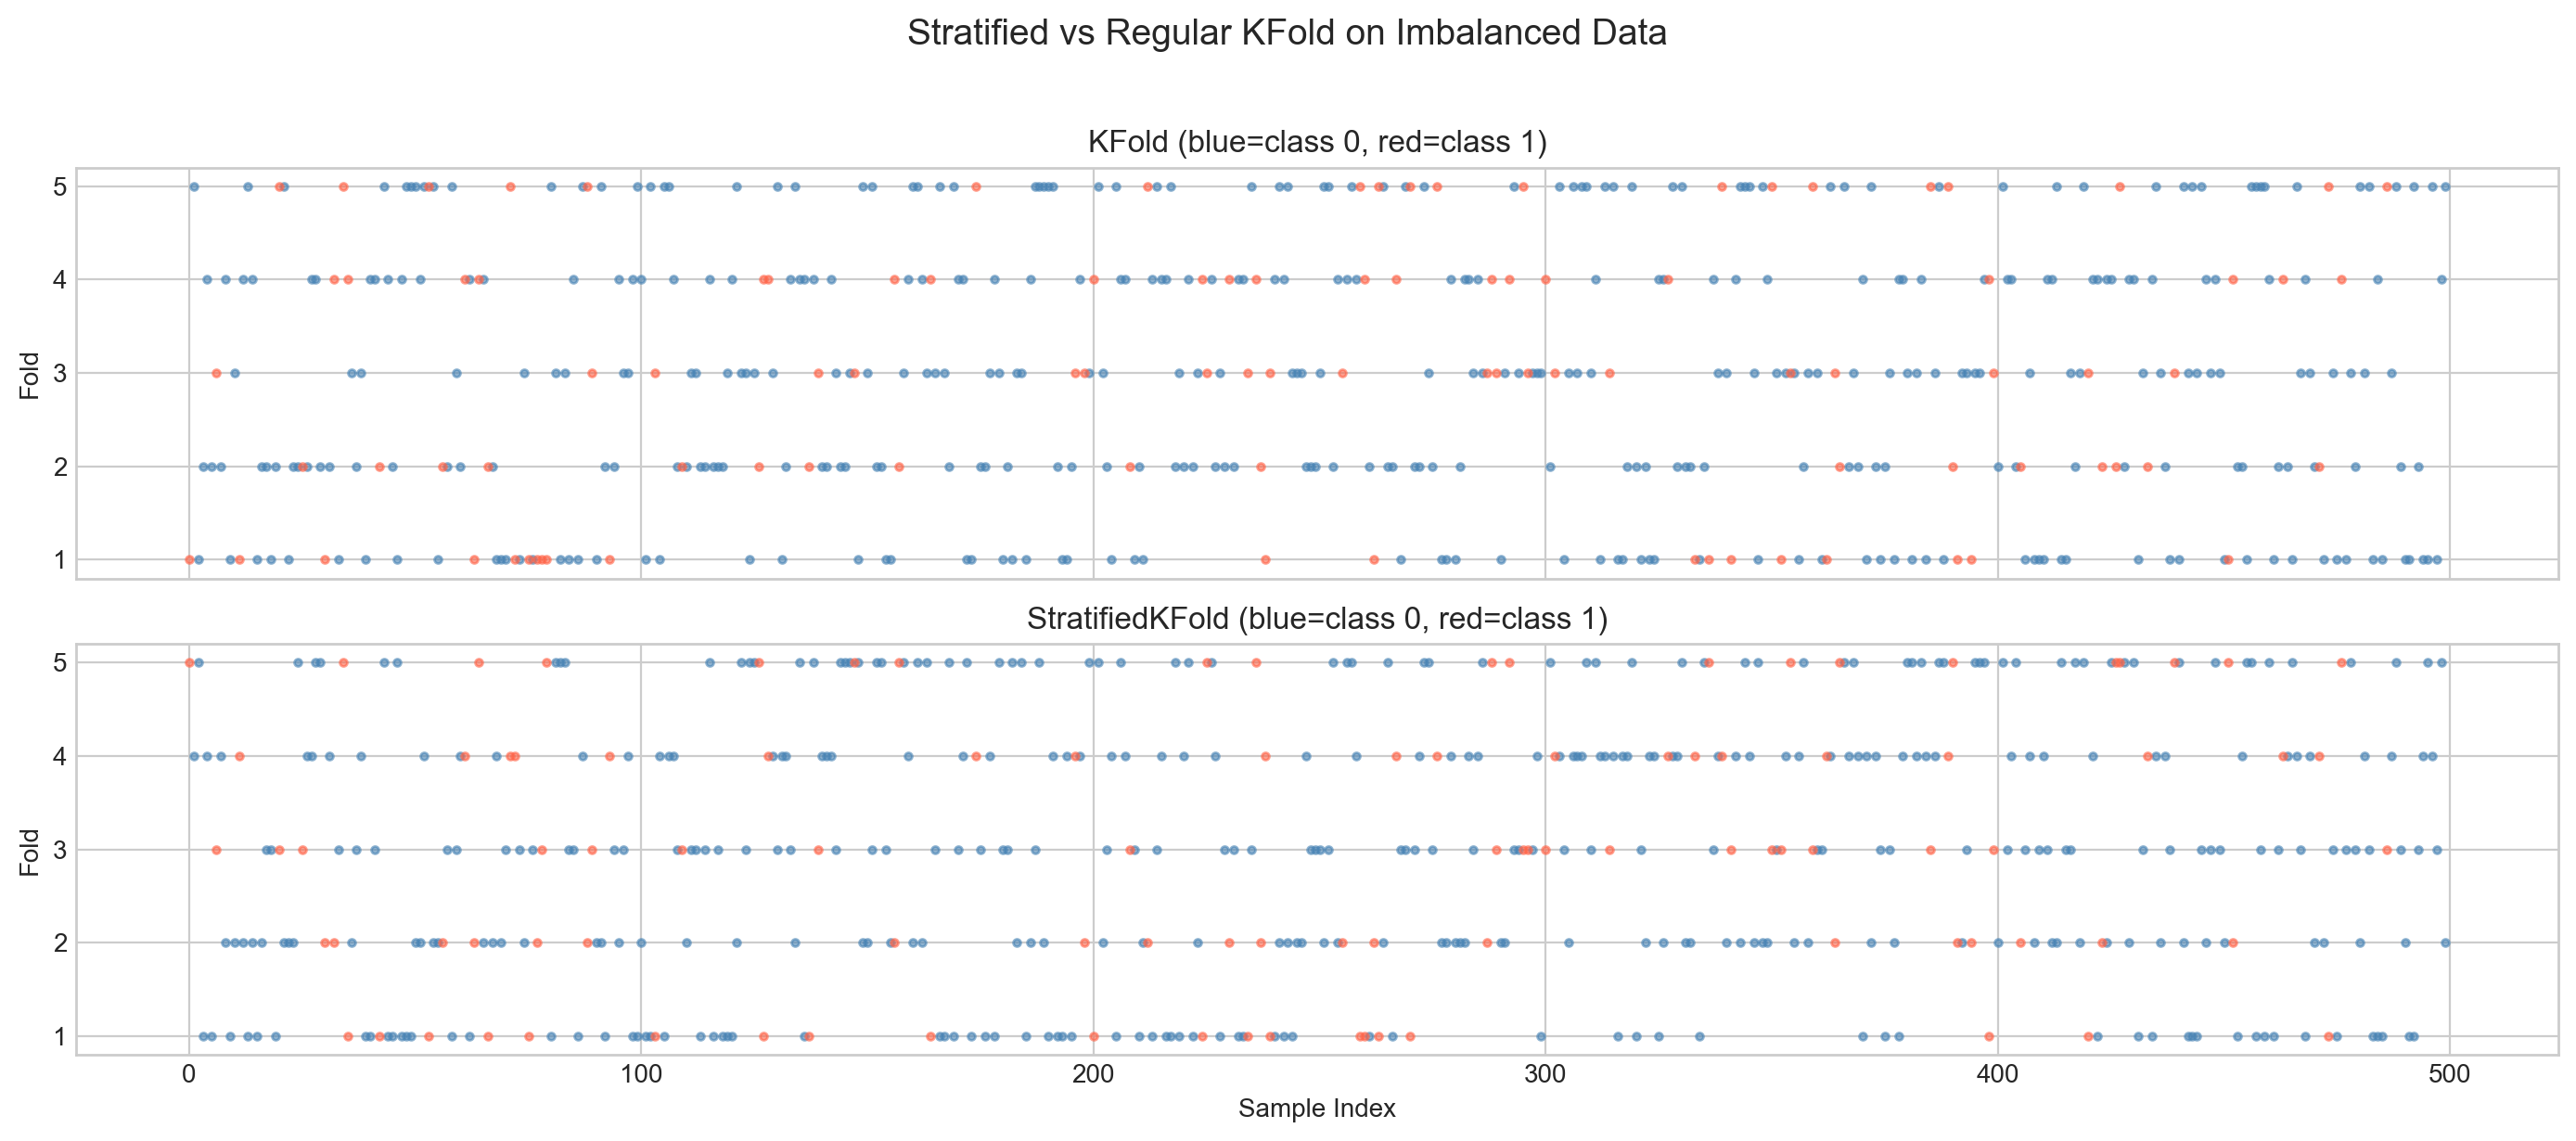

In [48]:
# Visualize the fold assignments
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, splitter, title in zip(axes, [kf, skf], ['KFold', 'StratifiedKFold']):
    for fold_i, (train_idx, test_idx) in enumerate(splitter.split(X_imb, y_imb)):
        # Plot test indices colored by class
        class0_test = test_idx[y_imb[test_idx] == 0]
        class1_test = test_idx[y_imb[test_idx] == 1]
        ax.scatter(class0_test, [fold_i + 1] * len(class0_test),
                   c='steelblue', s=8, alpha=0.6)
        ax.scatter(class1_test, [fold_i + 1] * len(class1_test),
                   c='tomato', s=8, alpha=0.6)
    ax.set_ylabel('Fold')
    ax.set_yticks(range(1, 6))
    ax.set_title(f'{title} (blue=class 0, red=class 1)', fontsize=12)

axes[1].set_xlabel('Sample Index')
fig.suptitle('Stratified vs Regular KFold on Imbalanced Data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6b. TimeSeriesSplit -- expanding window, no future leakage

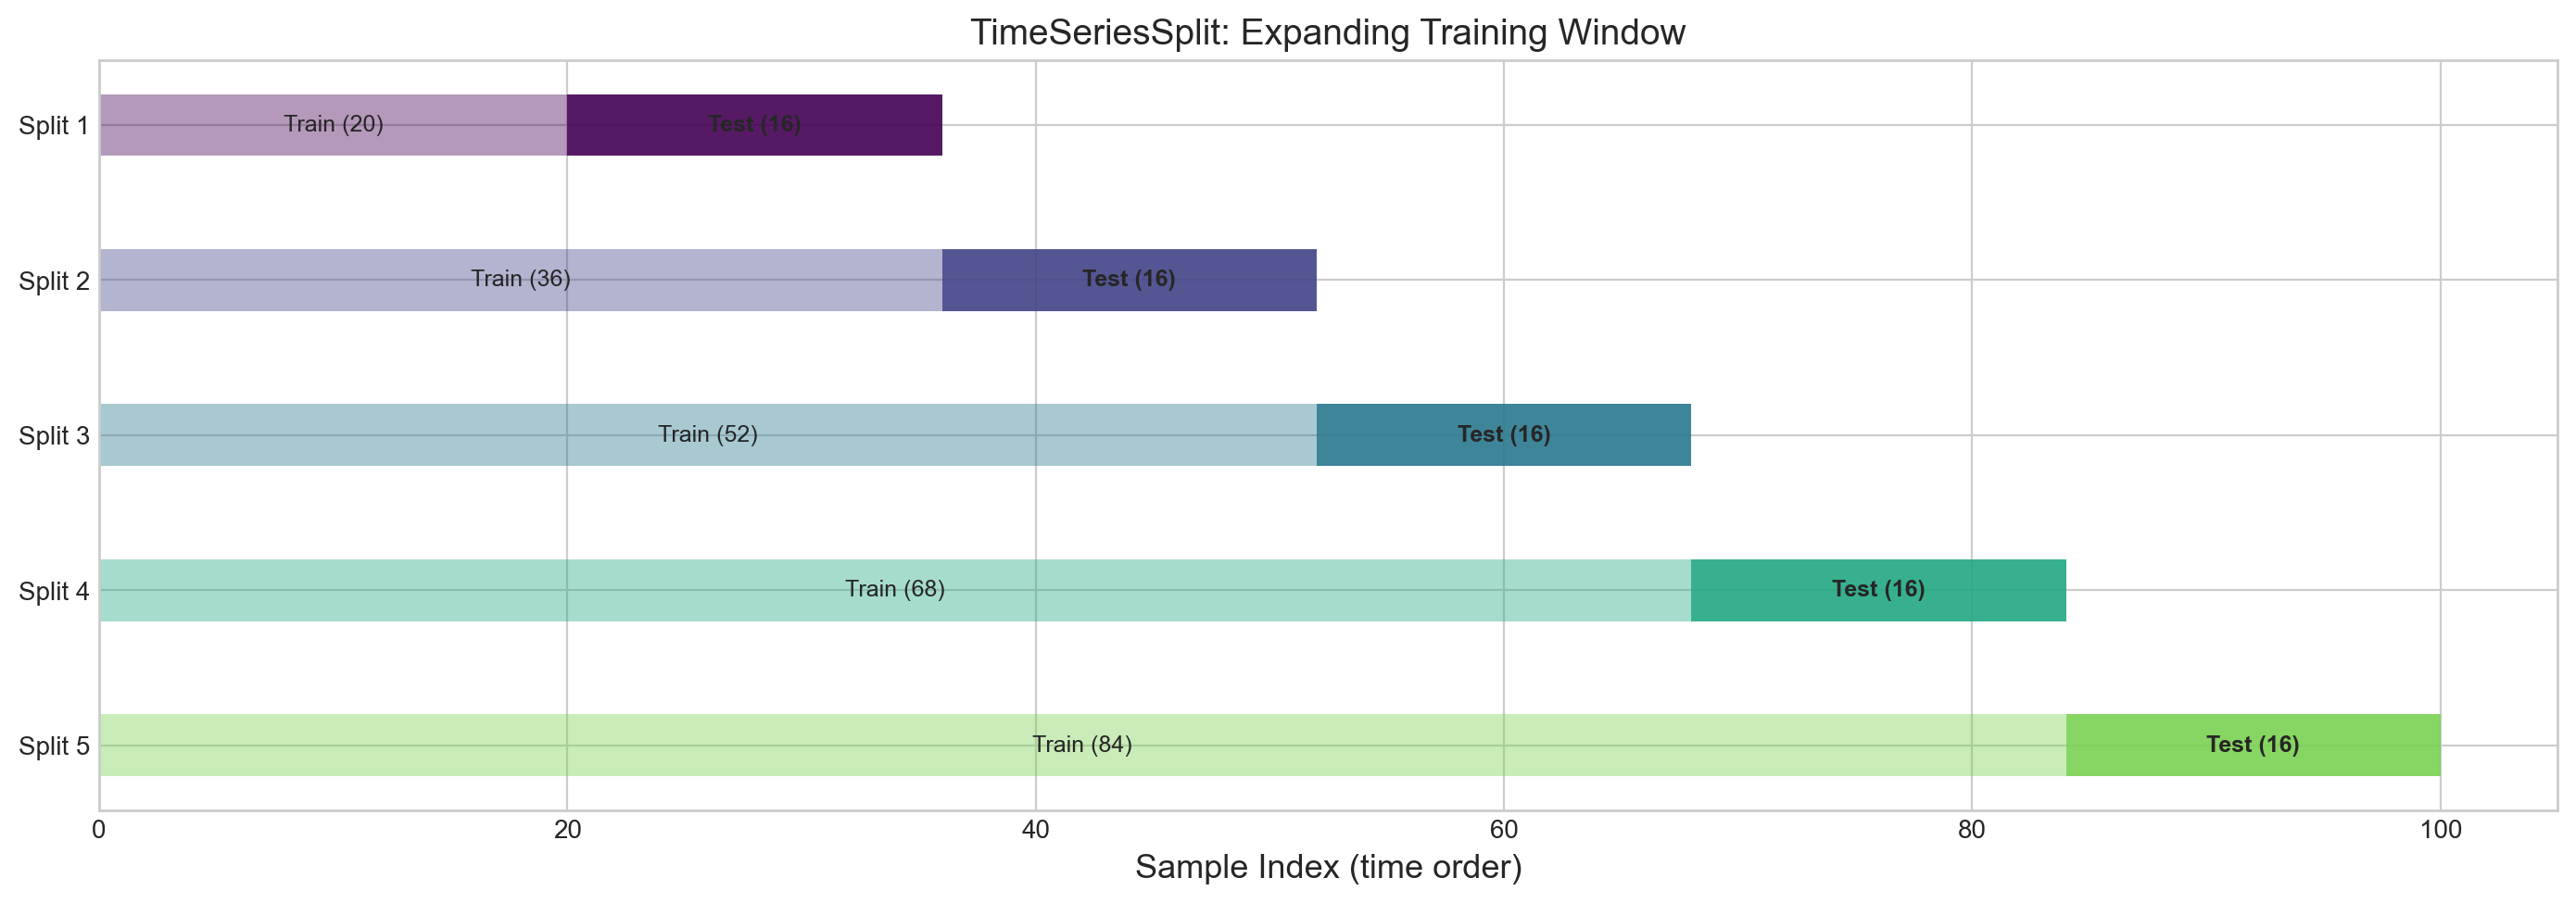

Key property: test set is ALWAYS in the future relative to training set.
Training window grows with each fold.


In [49]:
from sklearn.model_selection import TimeSeriesSplit

# Simulate a time series: samples are ordered by time
n_ts = 100
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.viridis

for fold_i, (train_idx, test_idx) in enumerate(tscv.split(range(n_ts))):
    color = cmap(fold_i / 5)
    ax.barh(fold_i, len(train_idx), left=train_idx[0], height=0.4,
            color=color, alpha=0.4, label='Train' if fold_i == 0 else '')
    ax.barh(fold_i, len(test_idx), left=test_idx[0], height=0.4,
            color=color, alpha=0.9, label='Test' if fold_i == 0 else '')
    
    # Annotate
    ax.text(train_idx[0] + len(train_idx)/2, fold_i,
            f'Train ({len(train_idx)})', ha='center', va='center', fontsize=9)
    ax.text(test_idx[0] + len(test_idx)/2, fold_i,
            f'Test ({len(test_idx)})', ha='center', va='center',
            fontsize=9, fontweight='bold')

ax.set_yticks(range(5))
ax.set_yticklabels([f'Split {i+1}' for i in range(5)])
ax.set_xlabel('Sample Index (time order)', fontsize=13)
ax.set_title('TimeSeriesSplit: Expanding Training Window', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Key property: test set is ALWAYS in the future relative to training set.")
print("Training window grows with each fold.")

---
## Summary

| Concept | Key Idea |
|---|---|
| **Single split** | Noisy -- score depends on the random seed |
| **Model complexity** | Too simple = underfit, too complex = overfit |
| **Validation set** | Tune hyperparameters on val, report on test (once) |
| **K-Fold CV** | More stable estimates, uses all data |
| **StratifiedKFold** | Preserves class balance in each fold |
| **TimeSeriesSplit** | Respects temporal order, no future leakage |
| **Validation curve** | Find the best hyperparameter value |